## Implementacja kd-drzewa (kd-tree)

In [24]:
from visualizer.main import Visualizer
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

Funkcje pomocnicze służące do wczytywania zbioru punktów za pomocą myszki.

In [25]:
%matplotlib tk

events = []
points = []
active = True

def draw_point(point) -> None:
    plt.scatter(point[0], point[1], color="red")
    plt.show()
    
def onclick(event) -> None:
    global active
    if event.button == 1 and active:
        x, y = event.xdata, event.ydata
        new_point = (x, y)
        points.append(new_point)
        draw_point(new_point)
    elif event.button == 3:
        active = False
        plt.pause(1)
        plt.close()
        
fig, ax = plt.subplots()
plt.get_current_fig_manager().set_window_title("Umieszczanie punktów na płaszczyźnie")
ax.set_title("LPM: Dodanie punktu\nPPM: Zakończenie")
connection_id = fig.canvas.mpl_connect("button_press_event", onclick)
ax.set_xlim([0, 10])
ax.set_ylim([0, 10])
plt.tight_layout()
plt.ion()
plt.show()  

[(np.float64(4.582914816114627), np.float64(3.878722848940056)), (np.float64(6.267471833286943), np.float64(5.270713105008263)), (np.float64(5.012767296358597), np.float64(5.792709451033842)), (np.float64(5.605266661019205), np.float64(4.2441202911579605)), (np.float64(5.686590103227524), np.float64(6.1581068932517455))]


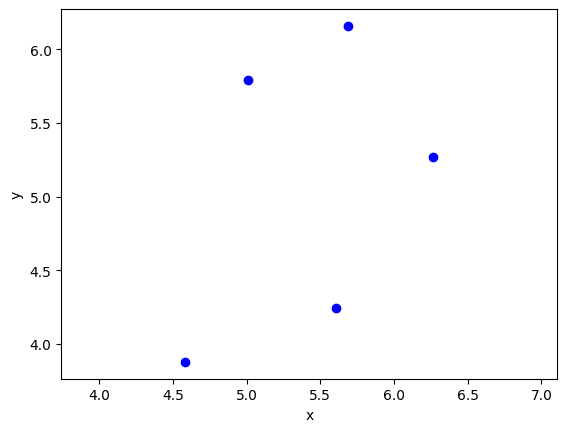

In [26]:
%matplotlib inline
print(points)
vis = Visualizer()
vis.axis_equal()
vis.add_point(points, color="blue")
vis.show()

Funkcje do wczytywania i odczytywania zbiorów punktów w plikach.

In [46]:
def write_points(name, points):   
    with open(f"saved_points/{name}.txt", "w", encoding="utf-8") as file:
        file.write(f"{points}")

def read_points(name): 
    with open(f"saved_points/{name}.txt", "r", encoding="utf-8") as file:
        points = eval(open(f"saved_points/{name}.txt").read())
    return points

Opcjonalny zapis.

In [ ]:
# name = input()
# write_points(name, points)

Funkcje pomocnicze do wczytywania zakresów obszaru za pomocą myszki.

In [27]:
%matplotlib tk

range_points = []

def draw_point(point):
    plt.scatter(point[0], point[1], color="red")
    plt.draw()
    
def onclick(event):
    global range_points

    if event.button == 1 and len(range_points) < 2:
        x, y = event.xdata, event.ydata
        if x is None or y is None:
            return

        new_point = (x, y)
        range_points.append(new_point)

        if len(range_points) == 2:
            plt.pause(1)
            plt.close()

fig, ax = plt.subplots()
plt.get_current_fig_manager().set_window_title("Wybieranie obszaru zapytania")
ax.set_title("1: lewy dolny róg\n2: prawy górny róg")
ax.set_xlim([0, 10])
ax.set_ylim([0, 10])

xs = [p[0] for p in points]
ys = [p[1] for p in points]
ax.scatter(xs, ys, color="red")

fig.canvas.mpl_connect("button_press_event", onclick)
plt.ion()
plt.show()

In [28]:
query_region = range_points[0][0], range_points[1][0], range_points[0][1], range_points[1][1]
print(query_region)

(np.float64(5.60483870967742), np.float64(7.204301075268818), np.float64(5.137085137085137), np.float64(6.868686868686869))


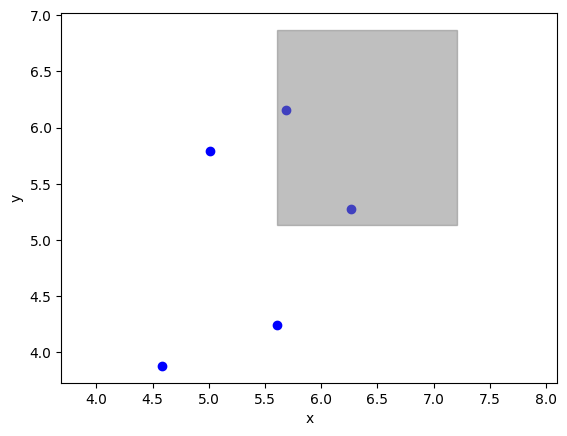

In [29]:
%matplotlib inline
vis = Visualizer()
vis.axis_equal()
vis.add_point(points, color="blue")

xmin, xmax, ymin, ymax = query_region
vis.add_polygon(((xmin, ymin), (xmin, ymax), (xmax, ymax), (xmax, ymin)), alpha = 0.5, color="grey")

vis.show()

Funkcje do zapisywania i wczytywania zakresów działania zapytania.

In [42]:
def write_region(name, query_region):   
    with open(f"saved_regions/{name}.txt", "w", encoding="utf-8") as file:
        file.write(f"{query_region}")

def read_region(name): 
    with open(f"saved_regions/{name}.txt", "r", encoding="utf-8") as file:
        query_region = eval(open(f"saved_regions/{name}.txt").read())
    return query_region

Opcjonalny zapis.

In [ ]:
# name = input()
# write_region(name, query_region)

Implementacja kd-drzew (kd-tree).

In [37]:
from kdtree import Kdtree

Przykładowy zbiór punktów oraz granice zapytania.

In [ ]:
# points = [(5, 5), (3, 7), (6, 3), (8, 8), (9, 9), (2, 3), (10, 1)]
# query_region = (1, 8, 1, 6)

Wizualizacja kd-drzewa (kd-tree).

In [31]:
kdtree = Kdtree(points)
default_region = (0, 10, 0, 10)

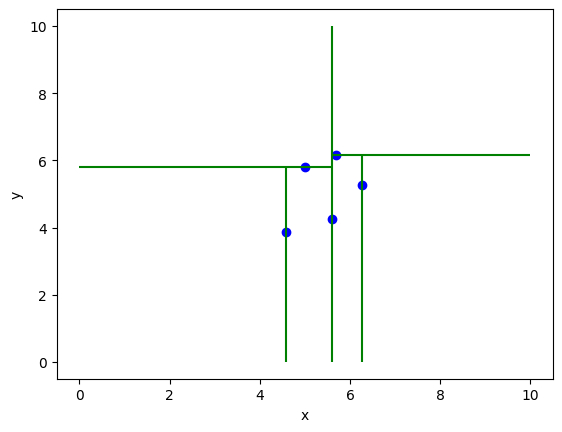

In [32]:
%matplotlib inline
vis = kdtree.visualize(default_region)
vis.show()

Wizualizacja poszczególnych kroków budowania drzewa.

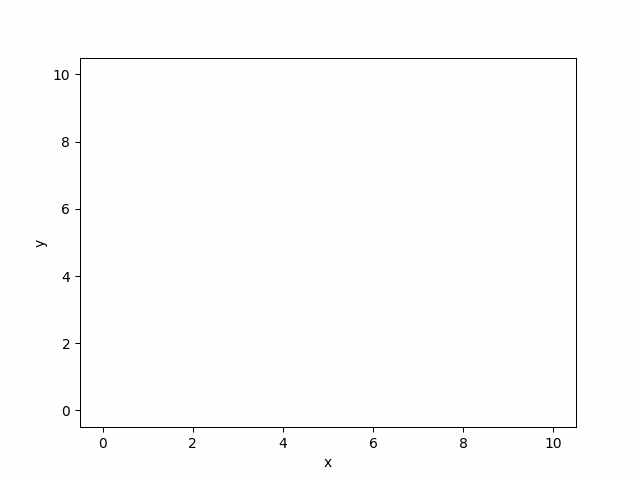

In [33]:
%matplotlib inline
vis.show_gif()

Znajdowanie punktów należących do zadanego obszaru w kształcie prostokąta.

In [44]:
result = kdtree.search(query_region, default_region)
print(result)

[(np.float64(5.686590103227524), np.float64(6.1581068932517455)), (np.float64(6.267471833286943), np.float64(5.270713105008263))]


Wizualizacja zbioru punktów należących do zadanego regionu.

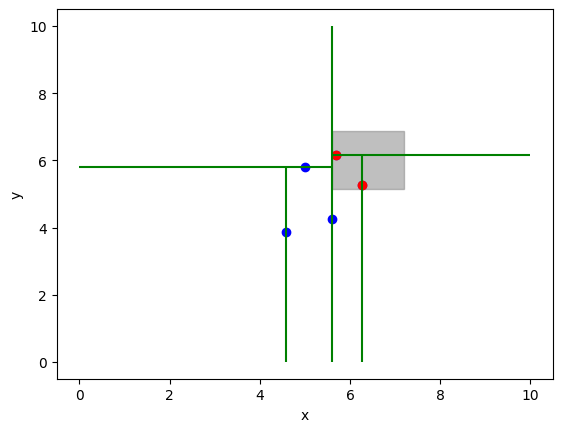

In [45]:
%matplotlib inline
vis = kdtree.search_vis(query_region, default_region)
vis.show()

Wizualizacja poszczególnych kroków szukania punktów należących do zadanego regionu.

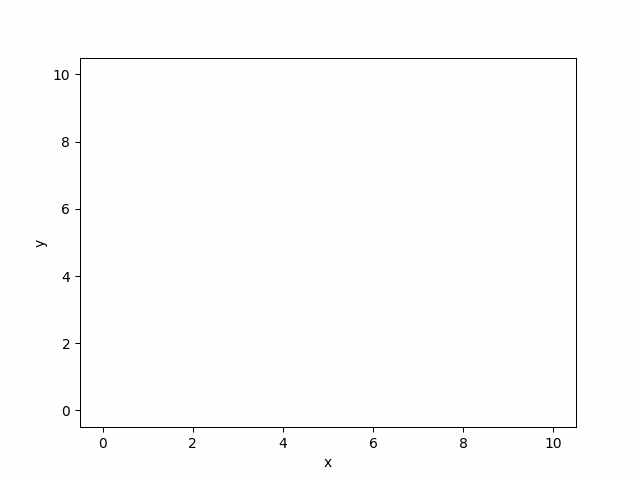

In [36]:
%matplotlib inline
vis.show_gif()